#  Rede Neural ADALINE — Classificação de Sinais para Ajuste de Válvulas A/B
**CEFET-MG Campus VIII – Varginha**  
**Disciplina:** Laboratório de Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  

---
##  Contexto do Problema
Um sistema envia sinais codificados de 4 grandezas $\{x_1, x_2, x_3, x_4\}$ para ajuste de duas válvulas (**A** e **B**).
Uma rede **ADALINE** é treinada via **Regra Delta (LMS)** com taxa $\eta = 0.0025$ e precisão $\epsilon = 10^{-6}$ para indicar ao comutador se o sinal é para:
- **Válvula A** (convenção: `-1`)
- **Válvula B** (convenção: `+1`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## ️ Implementação da Classe ADALINE

In [2]:
class Adaline:
    def __init__(self, eta=0.0025, precisao=1e-6, max_epocas=50000, bias_input=-1):
        self.eta = eta
        self.precisao = precisao
        self.max_epocas = max_epocas
        self.bias_input = bias_input
        self.w = None
        self.w_inicial = None
        self.historico_eqm = []
        self.epocas_executadas = 0

    def calcular_eqm(self, X, d):
        u = np.dot(X, self.w)
        return np.mean((d - u) ** 2)

    def treinar(self, X, d, seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        n_amostras, n_atributos = X.shape
        self.w = np.random.rand(n_atributos)
        self.w_inicial = self.w.copy()
        self.historico_eqm = []
        self.epocas_executadas = 0
        
        eqm_anterior = self.calcular_eqm(X, d)
        self.historico_eqm.append(eqm_anterior)
        
        for epoca in range(self.max_epocas):
            for i in range(n_amostras):
                u = np.dot(self.w, X[i])
                erro = d[i] - u
                self.w += self.eta * erro * X[i]
            
            eqm_atual = self.calcular_eqm(X, d)
            self.historico_eqm.append(eqm_atual)
            self.epocas_executadas += 1
            
            if abs(eqm_atual - eqm_anterior) < self.precisao:
                break
                
            eqm_anterior = eqm_atual
            
        return self

    def predizer(self, X):
        u = np.dot(X, self.w)
        return np.where(u >= 0, 1.0, -1.0)

##  Carregando o Conjunto de Treinamento

In [3]:
# Dados de treinamento (35 amostras)
dados_treino = np.array([
    [0.4329, -1.3719, 0.7022, -0.8535, 1.0],   [0.3024, 0.2286, 0.8630, 2.7909, -1.0],
    [0.1349, -0.6445, 1.0530, 0.5687, -1.0],   [0.3374, -1.7163, 0.3670, -0.6283, -1.0],
    [1.1434, -0.0485, 0.6637, 1.2606, 1.0],    [1.3749, -0.5071, 0.4464, 1.3009, 1.0],
    [0.7221, -0.7587, 0.7681, -0.5592, 1.0],   [0.4403, -0.8072, 0.5154, -0.3129, 1.0],
    [-0.5231, 0.3548, 0.2538, 1.5776, -1.0],   [0.3255, -2.0000, 0.7112, -1.1209, 1.0],
    [0.5824, 1.3915, -0.2291, 4.1735, -1.0],   [0.1340, 0.6081, 0.4450, 3.2230, -1.0],
    [0.1480, -0.2988, 0.4778, 0.8649, 1.0],    [0.7359, 0.1869, -0.0872, 2.3584, 1.0],
    [0.7115, -1.1469, 0.3394, 0.9573, -1.0],   [0.8251, -1.2840, 0.8452, 1.2382, -1.0],
    [0.1569, 0.3712, 0.8825, 1.7633, 1.0],     [0.0033, 0.6835, 0.5389, 2.8249, -1.0],
    [0.4243, 0.8313, 0.2634, 3.5855, -1.0],    [1.0490, 0.1326, 0.9138, 1.9792, 1.0],
    [1.4276, 0.5331, -0.0145, 3.7286, 1.0],    [0.5971, 1.4865, 0.2904, 4.6069, -1.0],
    [0.8475, 2.1479, 0.3179, 5.8235, -1.0],    [1.3967, -0.4171, 0.6443, 1.3927, 1.0],
    [0.0044, 1.5378, 0.6099, 4.7755, -1.0],    [0.2201, -0.5668, 0.0515, 0.7829, 1.0],
    [0.6300, -1.2480, 0.8591, 0.8093, -1.0],   [-0.2479, 0.8960, 0.0547, 1.7381, 1.0],
    [-0.3088, -0.0929, 0.8659, 1.5483, -1.0],  [-0.5180, 1.4974, 0.5453, 2.3993, 1.0],
    [0.6833, 0.8266, 0.0829, 2.8864, 1.0],     [0.4353, -1.4066, 0.4207, -0.4879, 1.0],
    [-0.1069, -3.2329, 0.1856, -2.4572, -1.0], [0.4662, 0.6261, 0.7304, 3.4370, -1.0],
    [0.8298, -1.4089, 0.3119, 1.3235, -1.0]
])

X_raw = dados_treino[:, :4]
d_treino = dados_treino[:, 4]
X_treino = np.hstack((np.full((X_raw.shape[0], 1), -1.0), X_raw))

print(f"Conjunto de Treinamento ADALINE: {X_treino.shape[0]} amostras carregadas.")

Conjunto de Treinamento ADALINE: 35 amostras carregadas.


##  Questões 1 e 2 — Execução e Registro dos 5 Treinamentos

In [4]:
seeds = [1, 2, 3, 4, 5]
modelos = []
tabela_q2 = []

for idx, seed in enumerate(seeds, 1):
    ada = Adaline(eta=0.0025, precisao=1e-6, max_epocas=50000)
    ada.treinar(X_treino, d_treino, seed=seed)
    modelos.append(ada)
    
    tabela_q2.append({
        'Treinamento': f'{idx}º (T{idx})',
        'w0 (Inicial)': f'{ada.w_inicial[0]:.4f}',
        'w1 (Inicial)': f'{ada.w_inicial[1]:.4f}',
        'w2 (Inicial)': f'{ada.w_inicial[2]:.4f}',
        'w3 (Inicial)': f'{ada.w_inicial[3]:.4f}',
        'w4 (Inicial)': f'{ada.w_inicial[4]:.4f}',
        'w0 (Final)': f'{ada.w[0]:.4f}',
        'w1 (Final)': f'{ada.w[1]:.4f}',
        'w2 (Final)': f'{ada.w[2]:.4f}',
        'w3 (Final)': f'{ada.w[3]:.4f}',
        'w4 (Final)': f'{ada.w[4]:.4f}',
        'Épocas': ada.epocas_executadas,
        'EQM Final': f'{ada.historico_eqm[-1]:.6f}'
    })

df_q2 = pd.DataFrame(tabela_q2)
display(df_q2.style.set_caption("Resultados dos 5 Treinamentos do ADALINE"))

,Treinamento,w0 (Inicial),w1 (Inicial),w2 (Inicial),w3 (Inicial),w4 (Inicial),w0 (Final),w1 (Final),w2 (Final),w3 (Final),w4 (Final),Épocas,EQM Final
0,1º (T1),0.4170,0.7203,0.0001,0.3023,0.1468,-1.8131,1.3129,1.6423,-0.4277,-1.1778,901,0.301998
1,2º (T2),0.4360,0.0259,0.5497,0.4353,0.4204,-1.8131,1.3129,1.6423,-0.4277,-1.1778,903,0.301998
2,3º (T3),0.5508,0.7081,0.2909,0.5108,0.8929,-1.8131,1.3129,1.6423,-0.4276,-1.1778,921,0.301998
3,4º (T4),0.9670,0.5472,0.9727,0.7148,0.6977,-1.8131,1.3129,1.6424,-0.4276,-1.1778,929,0.301998
4,5º (T5),0.2220,0.8707,0.2067,0.9186,0.4884,-1.8131,1.3129,1.6424,-0.4276,-1.1778,913,0.301998


##  Questão 3 — Gráfico do Erro Quadrático Médio (EQM) para T1 e T2

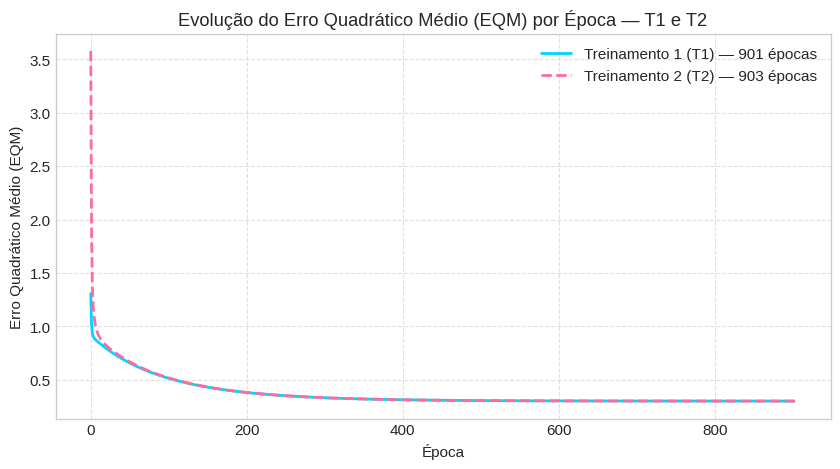

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(modelos[0].historico_eqm, label=f'Treinamento 1 (T1) — {modelos[0].epocas_executadas} épocas', color='#00d4ff', linewidth=2)
plt.plot(modelos[1].historico_eqm, label=f'Treinamento 2 (T2) — {modelos[1].epocas_executadas} épocas', color='#ff6b9d', linestyle='--', linewidth=2)

plt.title('Evolução do Erro Quadrático Médio (EQM) por Época — T1 e T2')
plt.xlabel('Época')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##  Questão 4 — Classificação das 15 Amostras de Sinais (Válvulas A e B)

In [6]:
# 15 amostras de teste do enunciado
amostras_teste_raw = np.array([
    [ 0.9694,  0.6909, 0.4334, 3.4965],
    [ 0.5427,  1.3832, 0.6390, 4.0352],
    [ 0.6081, -0.9196, 0.5925, 0.1016],
    [-0.1618,  0.4694, 0.2030, 3.0117],
    [ 0.1870, -0.2578, 0.6124, 1.7749],
    [ 0.4891, -0.5276, 0.4378, 0.6439],
    [ 0.3777,  2.0149, 0.7423, 3.3932],
    [ 1.1498, -0.4067, 0.2469, 1.5866],
    [ 0.9325,  1.0950, 1.0359, 3.3591],
    [ 0.5060,  1.3317, 0.9222, 3.7174],
    [ 0.0497, -2.0656, 0.6124,-0.6585],
    [ 0.4004,  3.5369, 0.9766, 5.3532],
    [-0.1874,  1.3343, 0.5374, 3.2189],
    [ 0.5060,  1.3317, 0.9222, 3.7174],
    [ 1.6375, -0.7911, 0.7537, 0.5515]
])

X_teste = np.hstack((np.full((amostras_teste_raw.shape[0], 1), -1.0), amostras_teste_raw))

tabela_q4 = []
for i in range(len(amostras_teste_raw)):
    linha = {
        'Amostra': i + 1,
        'x1': amostras_teste_raw[i, 0],
        'x2': amostras_teste_raw[i, 1],
        'x3': amostras_teste_raw[i, 2],
        'x4': amostras_teste_raw[i, 3]
    }
    saidas = []
    for t, m in enumerate(modelos, 1):
        y = m.predizer(X_teste[i])
        valvula = 'A' if y == -1 else 'B'
        linha[f'T{t}'] = valvula
        saidas.append(valvula)
    
    linha['Válvula Destino'] = 'Válvula A (-1)' if saidas[0] == 'A' else 'Válvula B (+1)'
    tabela_q4.append(linha)

df_q4 = pd.DataFrame(tabela_q4)
display(df_q4.style.set_caption("Classificação das 15 Amostras de Sinais do ADALINE"))

,Amostra,x1,x2,x3,x4,T1,T2,T3,T4,T5,Válvula Destino
0,1,0.969400,0.690900,0.433400,3.496500,A,A,A,A,A,Válvula A (-1)
1,2,0.542700,1.383200,0.639000,4.035200,A,A,A,A,A,Válvula A (-1)
2,3,0.608100,-0.919600,0.592500,0.101600,B,B,B,B,B,Válvula B (+1)
3,4,-0.161800,0.469400,0.203000,3.011700,A,A,A,A,A,Válvula A (-1)
4,5,0.187000,-0.257800,0.612400,1.774900,A,A,A,A,A,Válvula A (-1)
5,6,0.489100,-0.527600,0.437800,0.643900,B,B,B,B,B,Válvula B (+1)
6,7,0.377700,2.014900,0.742300,3.393200,B,B,B,B,B,Válvula B (+1)
7,8,1.149800,-0.406700,0.246900,1.586600,B,B,B,B,B,Válvula B (+1)
8,9,0.932500,1.095000,1.035900,3.359100,B,B,B,B,B,Válvula B (+1)
9,10,0.506000,1.331700,0.922200,3.717400,A,A,A,A,A,Válvula A (-1)


##  Questão 5 — Explicação de Por Que os Pesos Permanecem Inalterados no ADALINE

**Pergunta:** Embora o número de épocas de cada treinamento realizado no item 2 seja diferente, explique por que então os valores dos pesos continuam praticamente inalterados.

**Resposta:**  
Diferente do Perceptron (que utiliza a saída discreta com a regra de Hebb), o ADALINE minimiza o **Erro Quadrático Médio (EQM)** utilizando a **Regra Delta (Gradiente Descendente)** sobre a combinação linear contínua $u = w^T x$.

1. A superfície de erro do EQM no ADALINE é uma superfície **quadrática estritamente convexa** (um paraboloide $N$-dimensional).
2. Por ser estritamente convexa, a superfície possui **UM ÚNICO MÍNIMO GLOBAL** (mínimo absoluto). Não existem mínimos locais.
3. A solução analítica dos pesos ideais $w^*$ é única e dada pela Equação Normal dos Mínimos Quadrados:  
   $$w^* = (X^T X)^{-1} X^T d$$
4. Independentemente dos pesos iniciais (ponto de partida na superfície de erro), o algoritmo do Gradiente Descendente sempre desce a rampa de erro em direção ao mesmo ponto de mínimo global $w^*$.

**Por que as épocas variam ligeiramente (890 vs 918 épocas)?**  
Diferentes pesos iniciais partem de distâncias e trajetórias distintas na superfície parabólica. Isso faz com que alguns treinamentos precisem de algumas poucas iterações a mais para que a variação do EQM atinja a precisão $\epsilon = 10^{-6}$ fixada como critério de parada.